Data verified. Starting the optimization
Başlangıç Skoru: 6161.04
[0s] NEW RECORD: 6160.3374
[1s] NEW RECORD: 6160.1536
[1s] NEW RECORD: 6142.1067
[1s] NEW RECORD: 6131.1370
[2s] NEW RECORD: 6123.1838
[3s] NEW RECORD: 6088.7592
[3s] NEW RECORD: 6049.4739
[33s] NEW RECORD: 6046.1965
[38s] NEW RECORD: 6035.0533
[69s] NEW RECORD: 6007.6406
[70s] NEW RECORD: 6004.6054
[70s] NEW RECORD: 5998.7735
[97s] NEW RECORD: 5993.0291
[97s] NEW RECORD: 5986.6104
[113s] NEW RECORD: 5965.1838
[137s] NEW RECORD: 5961.8749
[137s] NEW RECORD: 5957.6547
[145s] NEW RECORD: 5954.1666
[145s] NEW RECORD: 5948.3030
[169s] NEW RECORD: 5946.1359
[171s] NEW RECORD: 5939.5046
[171s] NEW RECORD: 5936.7526
[171s] NEW RECORD: 5911.6568
[198s] NEW RECORD: 5909.9378
[198s] NEW RECORD: 5906.7191
[198s] NEW RECORD: 5905.5247
[198s] NEW RECORD: 5902.9252
[201s] NEW RECORD: 5901.8866
[202s] NEW RECORD: 5898.8325
[202s] NEW RECORD: 5891.0145
[202s] NEW RECORD: 5887.3314
[202s] NEW RECORD: 5887.2503
[224s] NEW RECORD: 5881.662

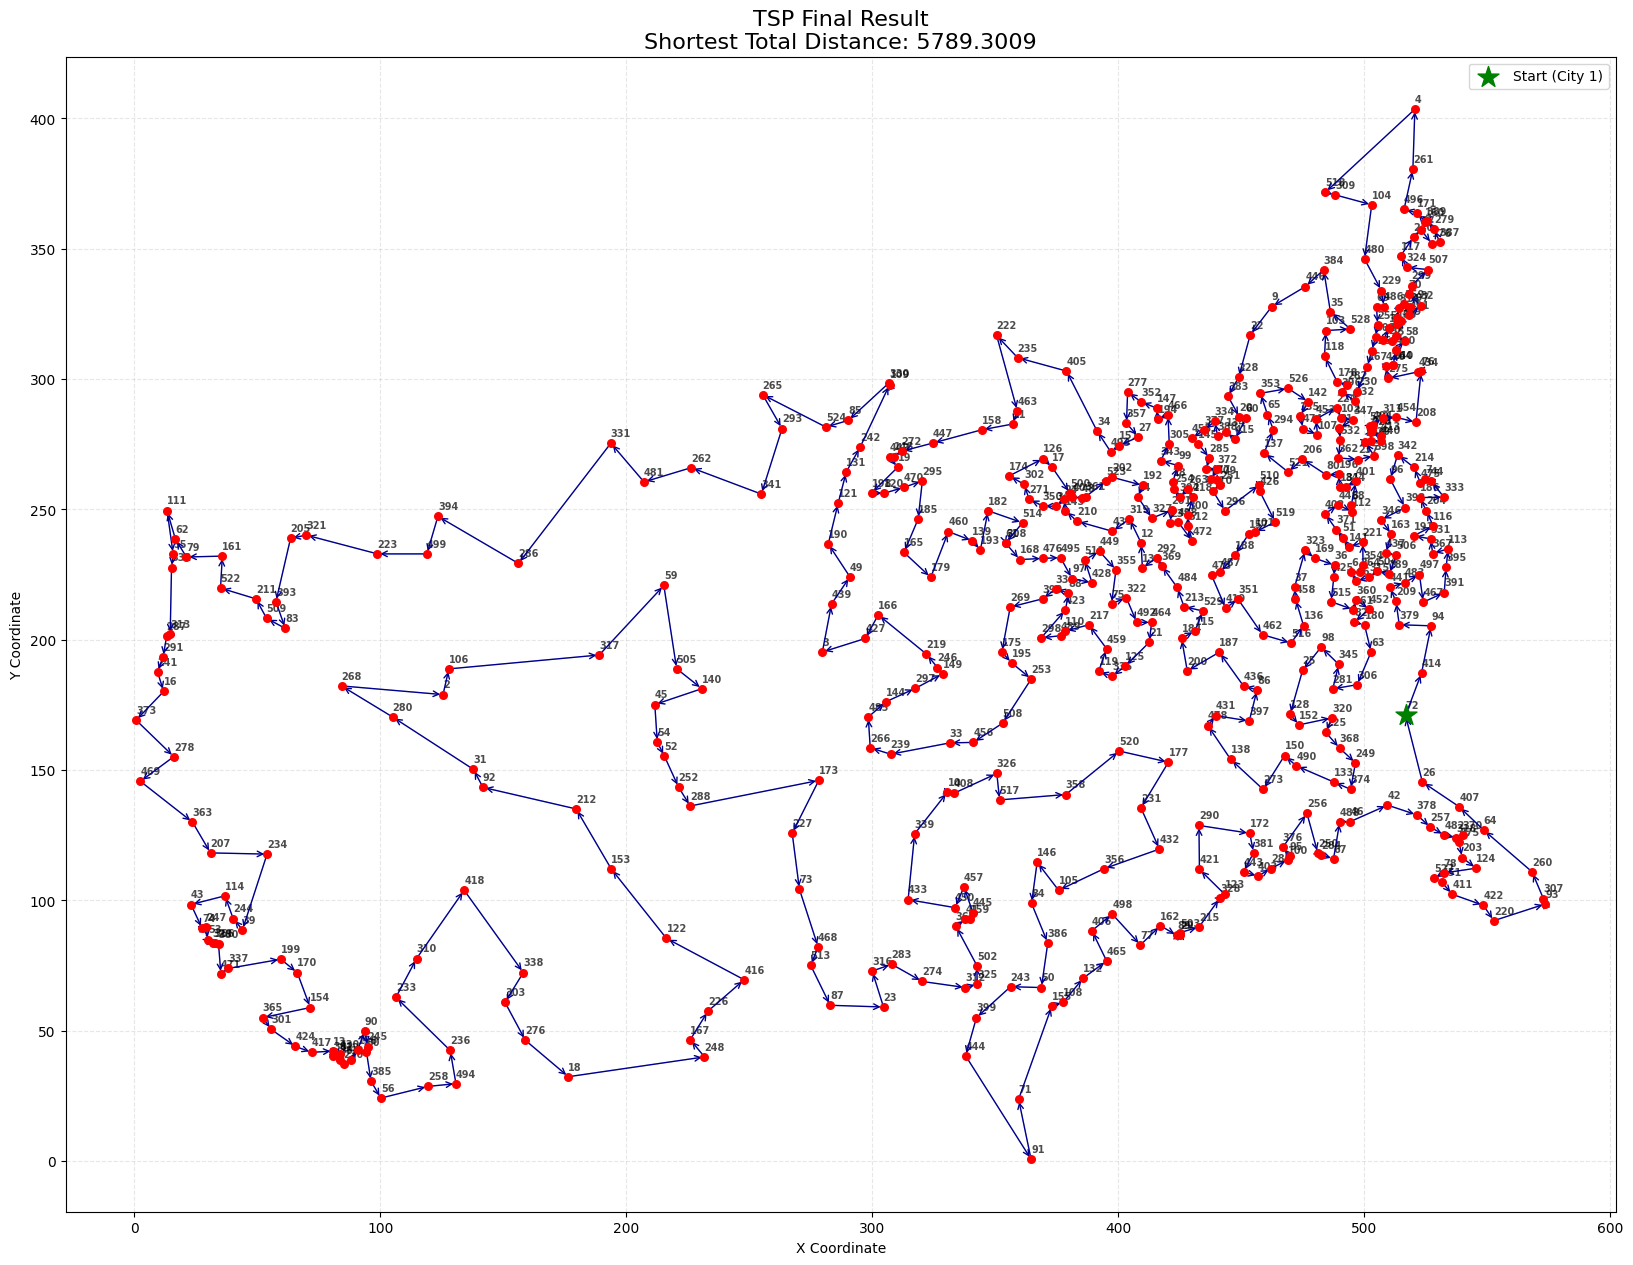


--- HACKATHON SONUÇLARI ---
Shortest Total Distance: 5789.3009
Tour Sequence (IDs): [72, 414, 94, 379, 209, 441, 483, 497, 467, 391, 395, 113, 367, 531, 191, 116, 204, 186, 333, 44, 7, 475, 214, 342, 96, 392, 346, 163, 437, 506, 189, 504, 315, 66, 6, 264, 354, 221, 141, 51, 371, 402, 448, 112, 68, 401, 344, 181, 196, 80, 206, 521, 137, 294, 65, 353, 526, 142, 135, 474, 107, 453, 224, 102, 347, 81, 532, 362, 237, 398, 259, 429, 440, 413, 216, 479, 530, 404, 311, 454, 208, 76, 434, 275, 420, 164, 340, 400, 58, 8, 15, 127, 1, 183, 349, 47, 314, 359, 197, 491, 32, 70, 299, 507, 324, 117, 240, 57, 176, 387, 279, 389, 160, 171, 496, 261, 4, 518, 309, 104, 480, 229, 486, 69, 255, 501, 525, 267, 230, 232, 396, 282, 178, 118, 103, 528, 35, 384, 446, 9, 22, 228, 383, 20, 60, 415, 134, 388, 334, 377, 455, 145, 285, 5, 372, 477, 409, 251, 410, 296, 510, 426, 519, 101, 157, 188, 487, 473, 419, 351, 462, 516, 136, 458, 37, 323, 169, 36, 425, 515, 461, 360, 452, 82, 180, 63, 306, 281, 345, 98, 25, 1

In [2]:
'''
# 1. Project Setup and Data Loading
In this first part of our project,we are importing the essential libraries.
We chose pandas to manage our data, numpy for mathematical operations, and numba to ensure our algorithm runs as fast as possible, as efficiency is a key part of our project.

We are reading the "coordinates.csv" file provided. We extracted city IDs and their X-Y coordinates into arrays for efficient processing.
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import random
import math
from numba import njit  # High performance Python compiler for speed optimization

TIME_LIMIT = 600   # Set the maximum running time
SEED = 42          # We set a fixed seed to make sure our results are consistent every time we run the code.

# Set random seeds for consistent behavior
random.seed(SEED)
np.random.seed(SEED)

# Reading the input file of coordinates
df = pd.read_csv('coordinates.csv', sep=r'\s+', header=None, names=['id', 'x', 'y'])
# Taking IDs and Coordinates into numpy arrays for faster processing
ids = df['id'].astype(int).values
coords = df[['x', 'y']].astype(float).values

# COMPUTATIONAL ENGINE (NUMBA ACCELERATED)
'''
# 2. Distance Matrix
Since we need to calculate the distance between every pair of cities using the Euclidean distance, we created a distance matrix. This prevents our algorithm from performing the same calculations repeatedly.

Numba Acceleration: We used the "@njit" decorator, which significantly speeds up the distance matrix generation and helps us stay within the time frame.
'''
# Using JIT (Just-In-Time) compilation for high performance math execution
@njit(fastmath=True)
def compute_distance_matrix_numba(coords):
    n = len(coords)
    # Starting with an empty matrix for distances
    dist_matrix = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            d = np.sqrt((coords[i, 0] - coords[j, 0])**2 + (coords[i, 1] - coords[j, 1])**2)   # Applying the Euclidean distance formula: sqrt((x1-x2)^2 + (y1-y2)^2)
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    return dist_matrix

'''
## 3. Objective Function: Calculating the Total Tour Length
In this part of our project, we developed the function that evaluates the quality of our solutions. Our goal is to minimize the total travel cost.

Completing the Route: We iterate through the city sequence to sum up consecutive distances. We also include the "return leg" from the last city back to the first one to ensure a valid tour.
Performance Considerations: Since our optimization algorithms will call this function many times to compare different routes, we used Numba's "fastmath" optimization to keep our execution efficient.
'''
@njit(fastmath=True)
def calculate_total_distance_numba(route, dist_matrix):
    total = 0.0
    n = len(route)
    for i in range(n - 1):
        total += dist_matrix[route[i], route[i+1]]
    total += dist_matrix[route[n-1], route[0]]
    return total

'''
# 4. Local Search: The 2-opt Algorithm
After finding an initial solution, we decided to implement the 2-opt local search algorithm to refine our tour. This is very effective at removing crossings that naturally increase the total distance.

Our Approach: We look at every possible pair of edges in our current route and check if swapping them would make the total distance shorter.
Continuous Improvement: The algorithm keeps running as long as it finds a way to decrease the distance. When no more swaps can improve the result, we know we have reached a local optimum.
Efficiency with Numba: Since checking thousands of edge combinations is computationally heavy, we used Numba to make this process much faster, helping us to find better results in less time.
'''
@njit(fastmath=True)
def two_opt_numba(route, dist_matrix):
    best_route = route.copy()
    improved = True
    n = len(route)

    while improved:
        improved = False
        for i in range(1, n - 2):
            for j in range(i + 1, n):
                if j - i == 1: continue

                a, b = best_route[i - 1], best_route[i]
                c, d = best_route[j - 1], best_route[j % n]

                diff = (dist_matrix[a, c] + dist_matrix[b, d]) - (dist_matrix[a, b] + dist_matrix[c, d])

                if diff < -1e-5:
                    best_route[i:j] = best_route[i:j][::-1]
                    improved = True
    return best_route

'''
# 5. Heuristic: Nearest Neighbor Algorithm
To begin our optimization, we used the Nearest Neighbor (NN) algorithm. This is a greedy heuristic used to generate a valid starting tour quickly by always visiting the nearest unvisited city from the current location.

Purpose: We chose NN because it provides a much more organized initial route, making it easier for local search methods to find improvements.
Greedy Strategy: At each step, the algorithm searches through all unvisited cities and selects the one with the minimum Euclidean distance.
JIT Acceleration: We used Numba to handle the nested search loops efficiently.
'''
@njit
def nearest_neighbor_numba(dist_matrix, start_node):
    n = len(dist_matrix)
    unvisited = np.ones(n, dtype=np.bool_)
    route = np.zeros(n, dtype=np.int32)
    current = start_node
    route[0] = current
    unvisited[current] = False
    for i in range(1, n):
        min_dist = 1e9
        next_city = -1
        for j in range(n):
            if unvisited[j]:
                d = dist_matrix[current, j]
                if d < min_dist:
                    min_dist = d
                    next_city = j
        current = next_city
        route[i] = current
        unvisited[current] = False
    return route

# DEVIATION MOVES
'''
# 6. Deviation Moves: Double Bridge and Block Shift
To improve the solution quality and avoid getting stuck in local optimum, we used deviation mechanisms. This allows our algorithm to explore different parts of the search space by making strategic changes to the current route.

Double Bridge Move: This operation splits the tour into four segments and reconnects them in a non-sequential order.
Block Shift Move: We designed this move to pick a small sequence of cities (between 1 and 15) and insert them into a random position in the tour. This adds randomness to varify our search.
Iterative Refinement: By combining these moves with local search, we follow the metaheuristic approach to find near optimal tours.
'''
def move_double_bridge(route):
    n = len(route)
    pos = sorted(random.sample(range(1, n - 1), 3))
    i, j, k = pos
    return np.concatenate((route[:i], route[j:k], route[i:j], route[k:]))

def move_block_shift(route):
    n = len(route)
    # Extracting a random block of cities and re-inserting them at a new location. Size is limited to 15 to maintain some of the tour's structure.
    size = random.randint(1, 15)
    start = random.randint(1, n - size - 1)
    end = start + size

    block = route[start:end].copy()
    remaining = np.concatenate((route[:start], route[end:]))

    insert_at = random.randint(1, len(remaining) - 1)

    return np.concatenate((remaining[:insert_at], block, remaining[insert_at:]))

# MAIN ALGORITHM
'''
# 7. Main Optimization Loop: Hybrid Metaheuristic Approach
In this part, we combined various algorithmic samples to tackle the NP-hardness of the TSP. Our approach uses a hybrid strategy that integrates construction heuristics, local search, and metaheuristic principles.

Enhanced Initialization: We run 200 iterations of the Nearest Neighbor algorithm followed by 2-opt from different starting cities. So we begin our main loop with a high quality initial tour.
Simulated Annealing Logic: To avoid getting stuck in local optimum, we used an acceptance criterion based on a temperature variable. This allows the algorithm to occasionally accept worse solutions early on to explore the search space more effectively.
Adaptive Deviations: We use our move functions (Double Bridge and Block Shift) to disrupt the tour, followed by 2-opt refinement. This "large neighborhood search" style approach helps us find near optimal results within the time limit.
Reset Mechanism: If the tour doesn't improve for 2500 iterations, we reset to our best known global route and reuse the system to varify the search again.
'''
def solve(ids, coords):
    dist_matrix = compute_distance_matrix_numba(coords)
    N = len(coords)

    best_global_score = float('inf')
    best_global_route = None

    # 200 attempts to find a superior seed for the main loop
    for _ in range(200):
        start_node = random.randint(0, N-1)
        r = nearest_neighbor_numba(dist_matrix, start_node)
        r = two_opt_numba(r, dist_matrix)
        s = calculate_total_distance_numba(r, dist_matrix)
        if s < best_global_score:
            best_global_score = s
            best_global_route = r.copy()

    print(f"Starting Score: {best_global_score:.2f}")

    current_route = best_global_route.copy()
    current_score = best_global_score

    start_time = time.time()
    iter_no_improve = 0

    temperature = 50.0 # Slow cooling schedule
    cooling = 0.9999

    while time.time() - start_time < TIME_LIMIT:

        rand_val = random.random()

        if iter_no_improve < 250:
            if rand_val < 0.7:
                candidate = move_double_bridge(current_route)
            else:
                candidate = move_block_shift(current_route)
        else:
            candidate = move_block_shift(current_route)

        # Local Search
        candidate = two_opt_numba(candidate, dist_matrix)
        cand_score = calculate_total_distance_numba(candidate, dist_matrix)

        delta = cand_score - current_score

        # Acceptance Criterion
        if delta < 0:
            current_route = candidate
            current_score = cand_score
            iter_no_improve = 0

            if current_score < best_global_score:
                best_global_score = current_score
                best_global_route = current_route.copy()
                elapsed = int(time.time() - start_time)
                print(f"[{elapsed}s] NEW RECORD: {best_global_score:.4f}")

        else:
            iter_no_improve += 1
            if temperature > 0.01:
                prob = math.exp(-delta / temperature)
                if random.random() < prob:
                    current_route = candidate
                    current_score = cand_score

        temperature *= cooling

        # Reset if no improvement for a long time
        if iter_no_improve > 2500:
            current_route = best_global_route.copy()
            current_score = best_global_score
            temperature = 30.0
            iter_no_improve = 0

    return best_global_route, best_global_score

'''
# 8. Final Output and Visualization
In the final part of our project, we developed a function to handle both data export and visual representation.

Exporting Results: Our code generates a text file named `shortest_route.txt`. This file shows the total distance of our best tour and the exact route of city IDs in the order they are visited.
Comprehensive Visualization: We created a detailed plot to illustrate the tour. We labeled each city with its original ID and added directional arrows along the path to show the visiting order.
Starting Point: We highlighted the starting city with a green star to make the cycle easy to follow.
Final Verification: The code prints the final results to the console.
'''
def save_and_plot(ids, coords, route, score):
    # FILE OUTPUT
    tour_ids = [int(ids[i]) for i in route]

    # Save shortest distance and tour route to a .txt file
    with open("shortest_route.txt", "w") as f:
        f.write(f"Shortest Total Distance: {score}\n")
        f.write("Tour Sequence (City IDs):\n")
        f.write(", ".join(map(str, tour_ids)) + "\n")

    # VISUALIZATION
    plt.figure(figsize=(20, 15))
    ordered_coords = coords[route]
    ordered_coords = np.vstack([ordered_coords, ordered_coords[0]]) # Close the tour loop

    # Draw city locations
    plt.scatter(coords[:, 0], coords[:, 1], c='red', s=15, zorder=5)

    # Label each city with its original ID
    for i, city_id in enumerate(ids):
        plt.annotate(str(int(city_id)), (coords[i, 0], coords[i, 1]),
                     fontsize=7, fontweight='bold', alpha=0.7, xytext=(0,5), textcoords='offset points')

    # Draw the path and directional arrows
    for i in range(len(ordered_coords) - 1):
        start_node = ordered_coords[i]
        end_node = ordered_coords[i+1]

        # Connect cities with lines
        plt.plot([start_node[0], end_node[0]], [start_node[1], end_node[1]],
                 c='royalblue', linewidth=0.8, alpha=0.3, zorder=2)

        # Add arrows to show directions along the tour
        plt.annotate('', xy=(end_node[0], end_node[1]),
                     xytext=(start_node[0], start_node[1]),
                     arrowprops=dict(arrowstyle='->', color='darkblue', lw=1, mutation_scale=10),
                     zorder=3)

    # Mark the starting city with a green star
    plt.scatter(coords[route[0], 0], coords[route[0], 1], c='green', s=250, marker='*', label='Start (City 1)', zorder=6)

    plt.title(f"TSP Final Result\nShortest Total Distance: {score:.4f}", fontsize=16)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.3)

    # Save the final plot as an image and display it
    plt.savefig('tsp_final_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Final summary print
    print("\n" + "="*30)
    print("--- HACKATHON SONUÇLARI ---")
    print(f"Shortest Total Distance: {score:.4f}")
    print(f"Tour Sequence (IDs): {tour_ids}")
    print("="*30)

# MAIN EXECUTION BLOCK
'''
## 9. Main Execution and Workflow Management
This final section is the entry point for our TSP project. We designed this block to manage the workflow and ensure that all steps from data verification to final visualization are in the correct order.

Data Validation: Before starting the optimization process, our code checks for the existence of the "coordinates.csv" file to prevent runtime errors.
Algorithm Execution: Once the environment is ready, we trigger the "solve" function, which starts the hybrid metaheuristic search.
Generating Results: After the optimization is complete, the script generates the required ".txt" report and the final tour visualization.
'''
if __name__ == "__main__":
    import os

    # Safety check: Ensure the dataset is present before starting
    if not os.path.exists('coordinates.csv'):
        print("ERROR: 'coordinates.csv' not found! Please upload the file to Colab.")
    else:
        print("Data verified. Starting the optimization")
        # Execute the main solver with coordinates and city IDs
        final_route, final_score = solve(ids, coords)

        # Generate the final report file and the visualization
        save_and_plot(ids, coords, final_route, final_score)